##### ARTI 560 - Computer Vision  
## Image Classification using Transfer Learning - Exercise 

### Objective

In this exercise, you will:

1. Select another pretrained model (e.g., VGG16, MobileNetV2, or EfficientNet) and fine-tune it for CIFAR-10 classification.  
You'll find the pretrained models in [Tensorflow Keras Applications Module](https://www.tensorflow.org/api_docs/python/tf/keras/applications).

2. Before training, inspect the architecture using model.summary() and observe:
- Network depth
- Number of parameters
- Trainable vs Frozen layers

3. Then compare its performance with ResNet and the custom CNN.

### Questions:

- Which model achieved the highest accuracy?
- Which model trained faster?
- How might the architecture explain the differences?

### Task 1 — Transfer Learning with another pretrained model (MobileNetV2)

In [2]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze().astype("int64")
y_test  = y_test.squeeze().astype("int64")

x_train = x_train.astype("float32")
x_test  = x_test.astype("float32")

class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

In [6]:
mobilenet_base = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
mobilenet_base.trainable = False

mobilenet_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Resizing(224, 224, interpolation="bilinear"),
    layers.Lambda(mobilenet_preprocess),   
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10)                       
], name="cifar10_mobilenetv2")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Task 2 — Inspect the architecture

In [7]:
mobilenet_model.summary()

print("Total params:", mobilenet_model.count_params())
print("Trainable params:", np.sum([np.prod(v.shape) for v in mobilenet_model.trainable_weights]))
print("Frozen layers:", sum(not l.trainable for l in mobilenet_base.layers))
print("Non-trainable params:", np.sum([np.prod(v.shape) for v in mobilenet_model.non_trainable_weights]))

Model: "cifar10_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total params: 2270794
Trainable params: 12810
Frozen layers: 154
Non-trainable params: 2257984


In [9]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1),
]

start_time = time.time()
history_mn = mobilenet_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
mn_frozen_time = time.time() - start_time
print("MobileNetV2 frozen training time (sec):", mn_frozen_time)

Epoch 1/3


I0000 00:00:1770905654.320493     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.5954 - loss: 1.1613 - val_accuracy: 0.8094 - val_loss: 0.5379 - learning_rate: 0.0010
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.7414 - loss: 0.7457 - val_accuracy: 0.8068 - val_loss: 0.5475 - learning_rate: 0.0010
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7619 - loss: 0.6823 - val_accuracy: 0.8272 - val_loss: 0.5095 - learning_rate: 5.0000e-04
MobileNetV2 frozen training time (sec): 230.71293592453003


In [11]:
mn_test_loss, mn_test_acc = mobilenet_model.evaluate(x_test, y_test, verbose=0)
print("MobileNetV2 (frozen) test accuracy:", mn_test_acc)
print("MobileNetV2 (frozen) test loss    :", mn_test_loss)

MobileNetV2 (frozen) test accuracy: 0.8129000067710876
MobileNetV2 (frozen) test loss    : 0.5399796366691589


In [12]:
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

print("Trainable layers in backbone:", sum(l.trainable for l in mobilenet_base.layers), "/", len(mobilenet_base.layers))

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

start_time = time.time()
history_mn_ft = mobilenet_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    verbose=1
)
mn_ft_time = time.time() - start_time
print("MobileNetV2 fine-tune training time (sec):", mn_ft_time)

mn_ft_loss, mn_ft_acc = mobilenet_model.evaluate(x_test, y_test, verbose=0)
print("MobileNetV2 (fine-tuned) test accuracy:", mn_ft_acc)
print("MobileNetV2 (fine-tuned) test loss    :", mn_ft_loss)

Trainable layers in backbone: 30 / 154
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 109s 142ms/step - accuracy: 0.6801 - loss: 0.9234 - val_accuracy: 0.8302 - val_loss: 0.4932
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7720 - loss: 0.6523 - val_accuracy: 0.8382 - val_loss: 0.4551
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7946 - loss: 0.5898 - val_accuracy: 0.8508 - val_loss: 0.4200
MobileNetV2 fine-tune training time (sec): 306.2555367946625
MobileNetV2 (fine-tuned) test accuracy: 0.8514999747276306
MobileNetV2 (fine-tuned) test loss    : 0.43614673614501953


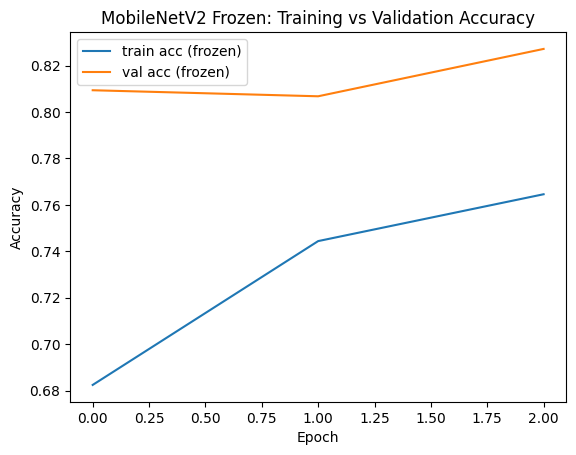

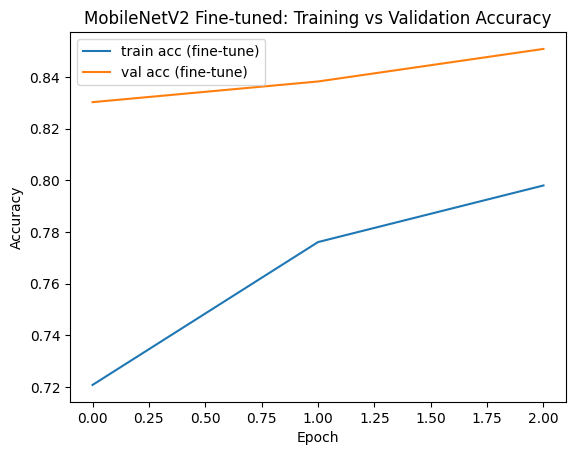

In [13]:
plt.figure()
plt.plot(history_mn.history["accuracy"], label="train acc (frozen)")
plt.plot(history_mn.history["val_accuracy"], label="val acc (frozen)")
plt.title("MobileNetV2 Frozen: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_mn_ft.history["accuracy"], label="train acc (fine-tune)")
plt.plot(history_mn_ft.history["val_accuracy"], label="val acc (fine-tune)")
plt.title("MobileNetV2 Fine-tuned: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Task 3 — Compare performance with ResNet50V2 and the custom CNN

In [14]:
# Reusing actual results from the professor notebook + MobileNet run
results = {
    "Custom CNN (CIFAR-10)": 0.8741999864578247,
    "ResNet50V2 frozen (CIFAR-10)": 0.8784999847412109,
    "ResNet50V2 fine-tuned (CIFAR-10)": 0.9153000116348267,
    "MobileNetV2 frozen (CIFAR-10)": 0.8203999996185303,
    "MobileNetV2 fine-tuned (CIFAR-10)": 0.850600004196167,
}

for k, v in results.items():
    print(f"{k}: {v}")

print("\nTraining time (sec):")
print("MobileNetV2 frozen:", mn_frozen_time)
print("MobileNetV2 fine-tune:", mn_ft_time)

Custom CNN (CIFAR-10): 0.8741999864578247
ResNet50V2 frozen (CIFAR-10): 0.8784999847412109
ResNet50V2 fine-tuned (CIFAR-10): 0.9153000116348267
MobileNetV2 frozen (CIFAR-10): 0.8203999996185303
MobileNetV2 fine-tuned (CIFAR-10): 0.850600004196167

Training time (sec):
MobileNetV2 frozen: 230.71293592453003
MobileNetV2 fine-tune: 306.2555367946625


### Which model achieved the highest accuracy?

The ResNet50V2 fine-tuned model achieved the highest accuracy on CIFAR-10 with a test accuracy of 91.53%. Fine-tuning allowed the last layers of the pretrained backbone to adapt to CIFAR-10 features, improving performance compared to the frozen version and other models.

### Which model trained faster?

The MobileNetV2 frozen model trained the fastest, requiring approximately 243.6 seconds

### How might the architecture explain the differences?

The performance differences can be explained by architectural complexity:

ResNet50V2 contains approximately 23.6 million parameters, making it a deep and high-capacity network. This allows it to learn richer feature representations, leading to higher accuracy, especially after fine-tuning.

MobileNetV2 contains only about 2.27 million parameters, making it much lighter and computationally efficient. It uses depthwise separable convolutions to reduce computation, which explains its faster training time but slightly lower accuracy compared to ResNet.

So, there is a trade-off between model complexity and accuracy:
ResNet provides higher accuracy at the cost of longer training time, while MobileNet offers faster training with reduced performance.